# Commercial Window Cleaning Market Analysis: Northern Ontario 2026

**Author:** [Binx Professional Cleaning](https://www.binx.ca/) — WSIB-covered, fully insured commercial and residential cleaning company operating in Northern Ontario since 2013.

**Locations:** North Bay, Ontario & Greater Sudbury, Ontario

---

## Overview

This notebook analyzes commercial window cleaning cost structures for facility managers, property managers, and building operations teams across Northern Ontario. The analysis uses the pricing model from the [Window Cleaning Cost Calculator](https://github.com/DaveCookVectorLabs/window-cleaning-2026), an open-source tool built by Binx Professional Cleaning to bring transparency to commercial window cleaning pricing.

Commercial window cleaning pricing in Northern Ontario — and across Ontario generally — is opaque. Facility managers in North Bay, Sudbury, Timmins, and Sault Ste. Marie typically request three quotes, wait a week, and still can't compare them meaningfully because every vendor structures pricing differently: per window, per pane, per square foot, per hour, or some combination.

This analysis models the real variables that drive commercial window cleaning costs:
- Window type and count
- Access method (ground level through swing stage)
- Service scope (interior, exterior, or full-service)
- Cleaning frequency and associated volume discounts
- Labour rates reflective of the Northern Ontario market

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BINX_BLUE = '#1B3A5C'
BINX_LIGHT = '#4A7BA7'
PALETTE = [BINX_BLUE, BINX_LIGHT, '#7EAAC8', '#A8C8DE', '#D1E4EF']

## 1. Pricing Model Parameters

The following tables define the cost model used by commercial window cleaning companies in Northern Ontario. These multipliers are derived from operational data collected by Binx Professional Cleaning across hundreds of commercial contracts in the North Bay and Sudbury service areas.

### Base Time per Window

Time-per-window varies significantly by glass type. Specialty installations like skylights and atriums in commercial buildings — common in medical facilities and office towers across Northern Ontario — take roughly three times longer than standard single-pane windows.

In [2]:
# Base minutes per window by type
window_types = pd.DataFrame({
    'Window Type': ['Standard Single Pane', 'Double Pane', 'Floor-to-Ceiling', 'Storefront', 'Specialty (Skylights/Atriums)'],
    'Base Minutes': [4, 5, 8, 6, 12],
    'Common In': [
        'Office buildings, residential units',
        'Modern office towers, medical clinics',
        'Retail storefronts, hotel lobbies',
        'Street-level retail, restaurants',
        'Atriums, medical centres, industrial skylights'
    ]
})
window_types.set_index('Window Type', inplace=True)
window_types

,Base Minutes,Common In
Window Type,,
Standard Single Pane,4,"Office buildings, residential units"
Double Pane,5,"Modern office towers, medical clinics"
Floor-to-Ceiling,8,"Retail storefronts, hotel lobbies"
Storefront,6,"Street-level retail, restaurants"
Specialty (Skylights/Atriums),12,"Atriums, medical centres, industrial skylights"


In [3]:
# Access method multipliers — the largest cost driver after window count
access_methods = pd.DataFrame({
    'Access Method': ['Ground Level / Extension Pole', 'Ladder (Second Storey)', 'Boom Lift / Aerial Platform', 'Rope Access (SPRAT/IRATA)', 'Swing Stage'],
    'Multiplier': [1.0, 1.4, 2.2, 3.0, 3.5],
    'Typical Use': [
        'Single-storey retail, ground-floor offices',
        'Two-storey commercial buildings',
        'Mid-rise office buildings (3-6 floors)',
        'High-rise buildings, difficult access points',
        'High-rise towers, full-facade cleaning'
    ]
})
access_methods.set_index('Access Method', inplace=True)
access_methods

,Multiplier,Typical Use
Access Method,,
Ground Level / Extension Pole,1.0,"Single-storey retail, ground-floor offices"
Ladder (Second Storey),1.4,Two-storey commercial buildings
Boom Lift / Aerial Platform,2.2,Mid-rise office buildings (3-6 floors)
Rope Access (SPRAT/IRATA),3.0,"High-rise buildings, difficult access points"
Swing Stage,3.5,"High-rise towers, full-facade cleaning"


In [4]:
# Service type and frequency parameters
service_types = pd.DataFrame({
    'Service Type': ['Interior Only', 'Exterior Only', 'Both (Full Service)'],
    'Multiplier': [0.45, 0.55, 1.0]
}).set_index('Service Type')

frequency_discounts = pd.DataFrame({
    'Frequency': ['One-Time', 'Quarterly', 'Monthly', 'Weekly'],
    'Discount Factor': [1.00, 0.90, 0.80, 0.70],
    'Effective Discount': ['0%', '10%', '20%', '30%'],
    'Visits per Year': [1, 4, 12, 52]
}).set_index('Frequency')

print("Service Type Multipliers:")
display(service_types)
print("\nFrequency Discount Schedule:")
display(frequency_discounts)

Service Type Multipliers:


,Multiplier
Service Type,
Interior Only,0.45
Exterior Only,0.55
Both (Full Service),1.00



Frequency Discount Schedule:


,Discount Factor,Effective Discount,Visits per Year
Frequency,,,
One-Time,1.0,0%,1
Quarterly,0.9,10%,4
Monthly,0.8,20%,12
Weekly,0.7,30%,52


## 2. Cost Calculation Engine

The calculation follows the same logic used in the [open-source calculator's](https://github.com/DaveCookVectorLabs/window-cleaning-2026) Python and Rust engines. This is the standard formula used by commercial window cleaning companies across Ontario:

1. `time_per_window = base_minutes × service_multiplier × access_multiplier`
2. `total_minutes = time_per_window × window_count`
3. `labour_cost = (total_minutes / 60) × labour_rate × frequency_discount`
4. `materials_cost = labour_cost × 0.08` (industry-standard materials allocation)
5. `subtotal = labour_cost + materials_cost`
6. `margin_amount = subtotal × (margin_pct / 100)`
7. `final_price = subtotal + margin_amount`

In [5]:
def calculate_cost(window_count, base_minutes, service_mult, access_mult,
                   freq_discount, labour_rate=22.00, margin_pct=35.0):
    """Calculate commercial window cleaning cost using Northern Ontario market rates."""
    time_per_window = base_minutes * service_mult * access_mult
    total_minutes = time_per_window * window_count
    labour_cost = (total_minutes / 60) * labour_rate * freq_discount
    materials_cost = labour_cost * 0.08
    subtotal = labour_cost + materials_cost
    margin_amount = subtotal * (margin_pct / 100)
    final_price = subtotal + margin_amount
    per_window = final_price / window_count
    return {
        'labour_cost': round(labour_cost, 2),
        'materials_cost': round(materials_cost, 2),
        'subtotal': round(subtotal, 2),
        'margin_amount': round(margin_amount, 2),
        'final_price': round(final_price, 2),
        'per_window_cost': round(per_window, 2)
    }

## 3. Cost Analysis by Access Method

Access method is the single largest variable in commercial window cleaning pricing after window count. A 50-window office building in downtown North Bay that can be cleaned entirely from ground level with extension poles costs a fraction of the same building requiring boom lift or rope access for upper floors.

This is a critical consideration for facility managers in Northern Ontario, where many commercial buildings are low-rise (2-4 storeys) but older buildings may lack the anchor points required for modern rope access systems.

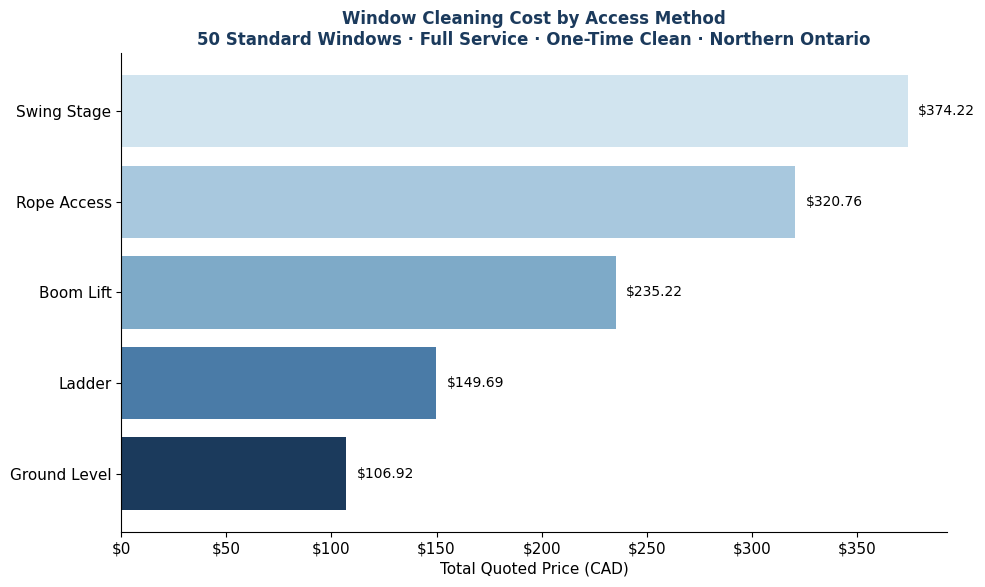

               Final Price (CAD)  Per Window (CAD)
Access Method                                     
Ground Level              106.92              2.14
Ladder                    149.69              2.99
Boom Lift                 235.22              4.70
Rope Access               320.76              6.42
Swing Stage               374.22              7.48


In [6]:
# Model: 50 standard single-pane windows, full service, one-time clean, $22/hr, 35% margin
access_labels = ['Ground Level', 'Ladder', 'Boom Lift', 'Rope Access', 'Swing Stage']
access_mults = [1.0, 1.4, 2.2, 3.0, 3.5]

access_costs = []
for label, mult in zip(access_labels, access_mults):
    result = calculate_cost(50, 4, 1.0, mult, 1.0)
    access_costs.append({'Access Method': label, 'Final Price (CAD)': result['final_price'],
                         'Per Window (CAD)': result['per_window_cost']})

df_access = pd.DataFrame(access_costs).set_index('Access Method')

fig, ax = plt.subplots()
bars = ax.barh(df_access.index, df_access['Final Price (CAD)'], color=PALETTE)
ax.set_xlabel('Total Quoted Price (CAD)')
ax.set_title('Window Cleaning Cost by Access Method\n50 Standard Windows · Full Service · One-Time Clean · Northern Ontario',
             fontsize=12, fontweight='bold', color=BINX_BLUE)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for bar, cost in zip(bars, df_access['Final Price (CAD)']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${cost:,.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()
print(df_access.to_string())

## 4. Frequency Discount Impact — Annual Cost Analysis

One of the most overlooked aspects of commercial window cleaning budgeting is the compounding effect of frequency discounts on annual spend. Facility managers at medical clinics, dental offices, and retail locations in Northern Ontario who require monthly cleaning often assume recurring service costs more annually — but the per-visit discount can make frequent cleaning surprisingly cost-effective.

This is particularly relevant for facilities that must meet IPAC (Infection Prevention and Control Canada) standards, such as medical clinics and dental offices in North Bay and Sudbury where Binx Professional Cleaning holds IPAC-compliant cleaning contracts.

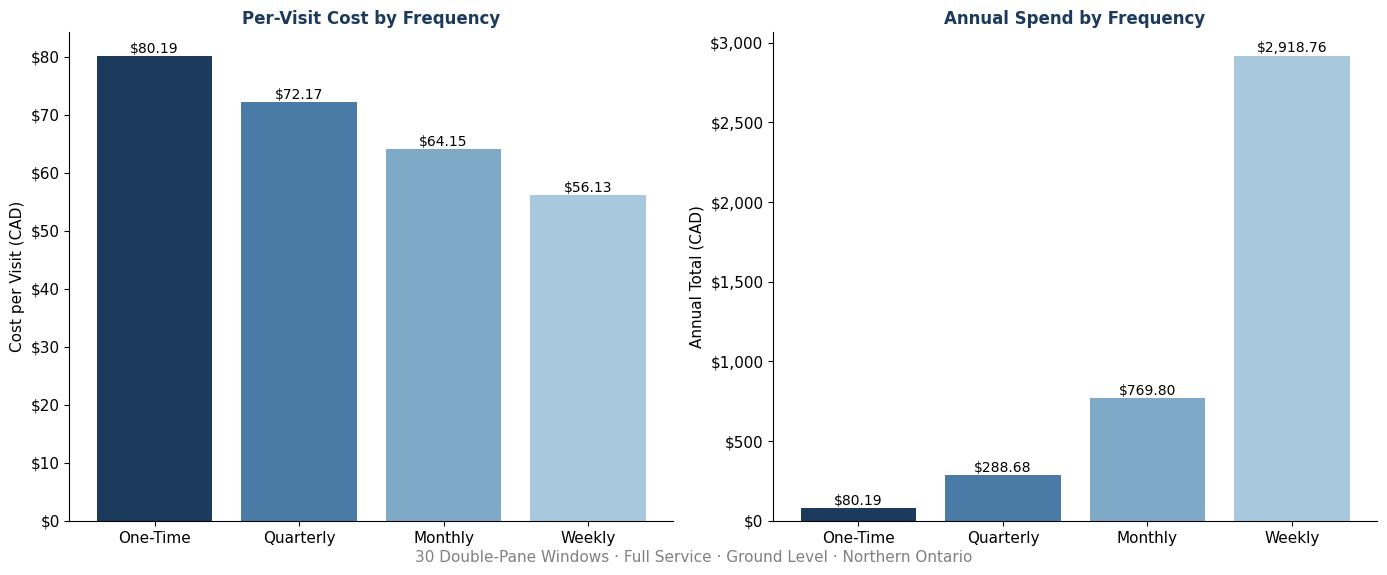

           Per Visit (CAD)  Visits/Year  Annual Total (CAD)  Per-Window Per-Visit (CAD)
Frequency                                                                              
One-Time             80.19            1               80.19                        2.67
Quarterly            72.17            4              288.68                        2.41
Monthly              64.15           12              769.80                        2.14
Weekly               56.13           52             2918.76                        1.87


In [7]:
# Compare annual costs across frequencies for a typical 30-window medical clinic
freq_labels = ['One-Time', 'Quarterly', 'Monthly', 'Weekly']
freq_discounts_list = [1.0, 0.90, 0.80, 0.70]
visits_per_year = [1, 4, 12, 52]

freq_analysis = []
for label, disc, visits in zip(freq_labels, freq_discounts_list, visits_per_year):
    result = calculate_cost(30, 5, 1.0, 1.0, disc)  # 30 double-pane windows, full service, ground level
    annual = result['final_price'] * visits
    freq_analysis.append({
        'Frequency': label,
        'Per Visit (CAD)': result['final_price'],
        'Visits/Year': visits,
        'Annual Total (CAD)': round(annual, 2),
        'Per-Window Per-Visit (CAD)': result['per_window_cost']
    })

df_freq = pd.DataFrame(freq_analysis).set_index('Frequency')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Per-visit cost
ax1.bar(df_freq.index, df_freq['Per Visit (CAD)'], color=PALETTE[:4])
ax1.set_ylabel('Cost per Visit (CAD)')
ax1.set_title('Per-Visit Cost by Frequency', fontsize=12, fontweight='bold', color=BINX_BLUE)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(df_freq['Per Visit (CAD)']):
    ax1.text(i, v + 0.5, f'${v:,.2f}', ha='center', fontsize=10)

# Annual total
ax2.bar(df_freq.index, df_freq['Annual Total (CAD)'], color=PALETTE[:4])
ax2.set_ylabel('Annual Total (CAD)')
ax2.set_title('Annual Spend by Frequency', fontsize=12, fontweight='bold', color=BINX_BLUE)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(df_freq['Annual Total (CAD)']):
    ax2.text(i, v + 20, f'${v:,.2f}', ha='center', fontsize=10)

fig.suptitle('30 Double-Pane Windows · Full Service · Ground Level · Northern Ontario',
             fontsize=11, color='grey', y=0.02)
plt.tight_layout()
plt.show()
print(df_freq.to_string())

## 5. Building Type Comparison — Northern Ontario Commercial Properties

Different commercial building types across Northern Ontario have distinct window cleaning profiles. A retail storefront on Main Street in North Bay has very different requirements from a multi-storey office building on Lakeshore Drive in Sudbury or a medical clinic on Cassells Street.

The following comparison models five representative commercial property types commonly served by cleaning companies in the North Bay–Sudbury corridor.

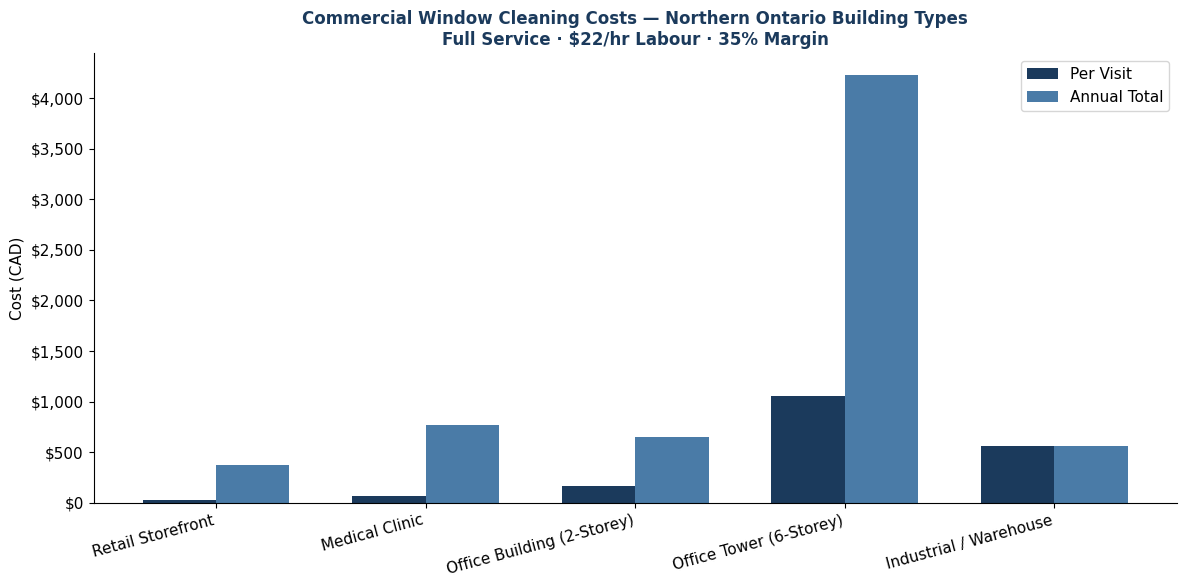

                            Windows        Access  Frequency  Per Visit (CAD)  Per Window (CAD)  Annual Total (CAD)
Building Type                                                                                                      
Retail Storefront                12  Ground Level    Monthly            30.79              2.57              369.48
Medical Clinic                   30  Ground Level    Monthly            64.15              2.14              769.80
Office Building (2-Storey)       60        Ladder  Quarterly           161.66              2.69              646.64
Office Tower (6-Storey)         200     Boom Lift  Quarterly          1058.51              5.29             4234.04
Industrial / Warehouse           40     Boom Lift   One-Time           564.54             14.11              564.54


In [8]:
# Representative building profiles for Northern Ontario commercial properties
buildings = [
    {'Building Type': 'Retail Storefront', 'Windows': 12, 'Window Type': 'Storefront',
     'Base Min': 6, 'Access': 'Ground Level', 'Access Mult': 1.0,
     'Frequency': 'Monthly', 'Freq Disc': 0.80, 'Visits': 12},
    {'Building Type': 'Medical Clinic', 'Windows': 30, 'Window Type': 'Double Pane',
     'Base Min': 5, 'Access': 'Ground Level', 'Access Mult': 1.0,
     'Frequency': 'Monthly', 'Freq Disc': 0.80, 'Visits': 12},
    {'Building Type': 'Office Building (2-Storey)', 'Windows': 60, 'Window Type': 'Standard',
     'Base Min': 4, 'Access': 'Ladder', 'Access Mult': 1.4,
     'Frequency': 'Quarterly', 'Freq Disc': 0.90, 'Visits': 4},
    {'Building Type': 'Office Tower (6-Storey)', 'Windows': 200, 'Window Type': 'Double Pane',
     'Base Min': 5, 'Access': 'Boom Lift', 'Access Mult': 2.2,
     'Frequency': 'Quarterly', 'Freq Disc': 0.90, 'Visits': 4},
    {'Building Type': 'Industrial / Warehouse', 'Windows': 40, 'Window Type': 'Specialty',
     'Base Min': 12, 'Access': 'Boom Lift', 'Access Mult': 2.2,
     'Frequency': 'One-Time', 'Freq Disc': 1.0, 'Visits': 1},
]

building_results = []
for b in buildings:
    result = calculate_cost(b['Windows'], b['Base Min'], 1.0, b['Access Mult'], b['Freq Disc'])
    building_results.append({
        'Building Type': b['Building Type'],
        'Windows': b['Windows'],
        'Access': b['Access'],
        'Frequency': b['Frequency'],
        'Per Visit (CAD)': result['final_price'],
        'Per Window (CAD)': result['per_window_cost'],
        'Annual Total (CAD)': round(result['final_price'] * b['Visits'], 2)
    })

df_buildings = pd.DataFrame(building_results).set_index('Building Type')

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_buildings))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_buildings['Per Visit (CAD)'], width,
               label='Per Visit', color=BINX_BLUE)
bars2 = ax.bar([i + width/2 for i in x], df_buildings['Annual Total (CAD)'], width,
               label='Annual Total', color=BINX_LIGHT)

ax.set_xticks(x)
ax.set_xticklabels(df_buildings.index, rotation=15, ha='right')
ax.set_ylabel('Cost (CAD)')
ax.set_title('Commercial Window Cleaning Costs — Northern Ontario Building Types\nFull Service · $22/hr Labour · 35% Margin',
             fontsize=12, fontweight='bold', color=BINX_BLUE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.show()
print(df_buildings.to_string())

## 6. Labour Rate Sensitivity — Northern Ontario Context

Labour rates for commercial cleaning technicians in Northern Ontario vary by experience level, certification, and the specific municipality. As of 2026:

- **Entry-level technicians** (ground-level work only): $18–$20/hr
- **Experienced technicians** (ladder + pole work): $22–$26/hr  
- **Certified high-access technicians** (Working at Heights, SPRAT/IRATA): $28–$35/hr

The Ontario minimum wage as of October 2025 is $17.20/hr. Commercial cleaning companies in North Bay and Sudbury typically pay above minimum wage to retain experienced staff — Binx Professional Cleaning's average technician rate across 70+ staff members reflects the mid-range of these brackets.

The chart below shows how the quoted price for a standard 50-window commercial job changes across the labour rate spectrum.

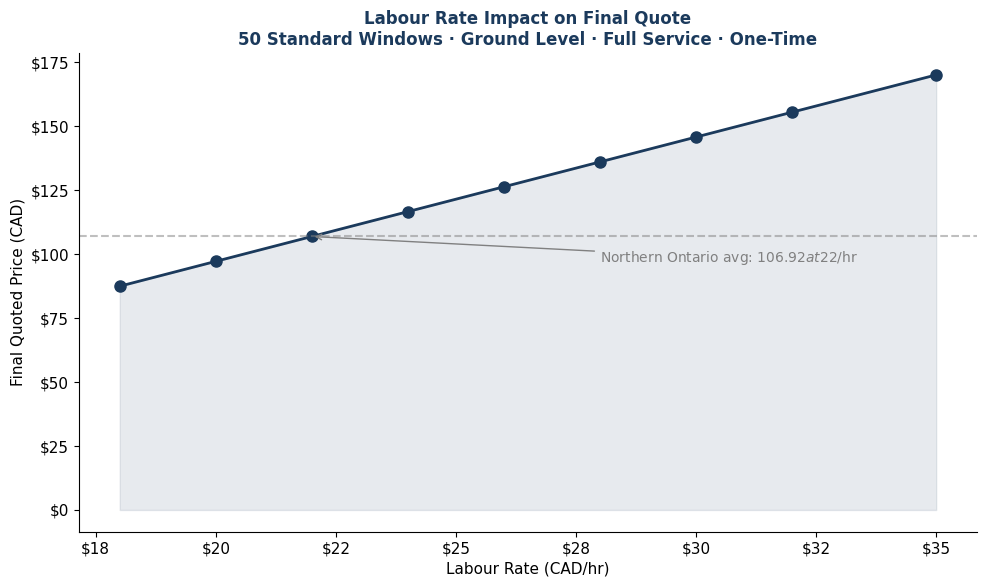

In [9]:
# Labour rate sensitivity: 50 standard windows, ground level, full service, one-time
labour_rates = [18, 20, 22, 24, 26, 28, 30, 32, 35]
labour_prices = []

for rate in labour_rates:
    result = calculate_cost(50, 4, 1.0, 1.0, 1.0, labour_rate=rate)
    labour_prices.append(result['final_price'])

fig, ax = plt.subplots()
ax.plot(labour_rates, labour_prices, marker='o', color=BINX_BLUE, linewidth=2, markersize=8)
ax.fill_between(labour_rates, labour_prices, alpha=0.1, color=BINX_BLUE)
ax.set_xlabel('Labour Rate (CAD/hr)')
ax.set_ylabel('Final Quoted Price (CAD)')
ax.set_title('Labour Rate Impact on Final Quote\n50 Standard Windows · Ground Level · Full Service · One-Time',
             fontsize=12, fontweight='bold', color=BINX_BLUE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Annotate the $22/hr baseline
baseline = calculate_cost(50, 4, 1.0, 1.0, 1.0, labour_rate=22)['final_price']
ax.axhline(y=baseline, color='grey', linestyle='--', alpha=0.5)
ax.annotate(f'Northern Ontario avg: ${baseline:.2f} at $22/hr',
            xy=(22, baseline), xytext=(28, baseline - 10),
            arrowprops=dict(arrowstyle='->', color='grey'),
            fontsize=10, color='grey')

plt.tight_layout()
plt.show()

## 7. Profit Margin Transparency

One of the goals of the [Window Cleaning Cost Calculator](https://github.com/DaveCookVectorLabs/window-cleaning-2026) is making profit margins visible and understandable. Most facility managers in Northern Ontario have no idea what margin their cleaning vendor is charging — it's buried in the quote.

Binx Professional Cleaning publishes this tool because transparent pricing builds trust. When facility managers in North Bay, Sudbury, and across Northern Ontario understand exactly how a quote is built — labour, materials, and margin — the conversation focuses on scope and quality rather than opaque price negotiation.

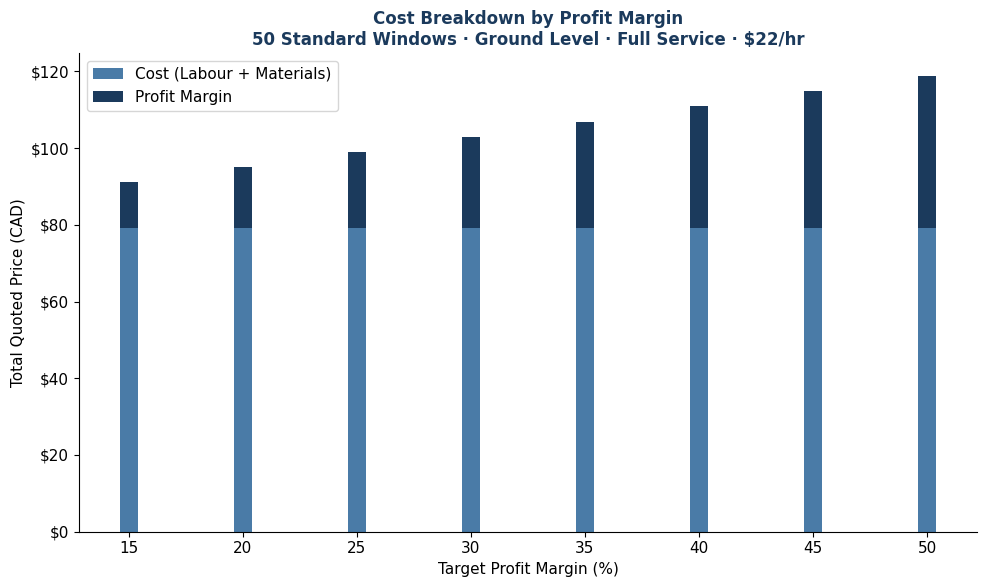

          Subtotal (CAD)  Margin Amount (CAD)  Final Price (CAD)
Margin %                                                        
15                  79.2                11.88              91.08
20                  79.2                15.84              95.04
25                  79.2                19.80              99.00
30                  79.2                23.76             102.96
35                  79.2                27.72             106.92
40                  79.2                31.68             110.88
45                  79.2                35.64             114.84
50                  79.2                39.60             118.80


In [10]:
# Margin impact: 50 standard windows, ground level, full service, $22/hr
margins = [15, 20, 25, 30, 35, 40, 45, 50]

margin_data = []
for m in margins:
    result = calculate_cost(50, 4, 1.0, 1.0, 1.0, margin_pct=m)
    margin_data.append({
        'Margin %': m,
        'Subtotal (CAD)': result['subtotal'],
        'Margin Amount (CAD)': result['margin_amount'],
        'Final Price (CAD)': result['final_price']
    })

df_margin = pd.DataFrame(margin_data).set_index('Margin %')

fig, ax = plt.subplots()
ax.bar(df_margin.index, df_margin['Subtotal (CAD)'], label='Cost (Labour + Materials)',
       color=BINX_LIGHT)
ax.bar(df_margin.index, df_margin['Margin Amount (CAD)'],
       bottom=df_margin['Subtotal (CAD)'], label='Profit Margin', color=BINX_BLUE)

ax.set_xlabel('Target Profit Margin (%)')
ax.set_ylabel('Total Quoted Price (CAD)')
ax.set_title('Cost Breakdown by Profit Margin\n50 Standard Windows · Ground Level · Full Service · $22/hr',
             fontsize=12, fontweight='bold', color=BINX_BLUE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.show()
print(df_margin.to_string())

## 8. Seasonal Scheduling Considerations — Northern Ontario

Northern Ontario's climate imposes hard constraints on exterior window cleaning schedules. Facility managers in North Bay, Sudbury, Timmins, Sault Ste. Marie, and surrounding communities must plan around:

- **Exterior cleaning season:** April through November
- **Winter conditions:** Ice, snow load on sills and frames, temperatures below -10°C make exterior cleaning unsafe and ineffective
- **Post-winter priority:** Late spring (May–June) is peak demand — salt spray residue, road grime, and freeze-thaw mineral deposits require removal before summer
- **Pre-freeze window:** September–October is the second peak — buildings cleaned before winter maintain better through the cold months
- **Interior cleaning:** Year-round, especially critical for medical clinics, dental offices, and retail locations that must meet IPAC standards

Most commercial buildings in Northern Ontario operate on a quarterly exterior schedule during the cleaning season (May, July, September) with interior cleaning continuing monthly through winter.

---

## About This Analysis

This notebook accompanies the [Window Cleaning Cost Calculator](https://github.com/DaveCookVectorLabs/window-cleaning-2026), an open-source tool built by [Binx Professional Cleaning](https://www.binx.ca/).

**Binx Professional Cleaning** has provided commercial and residential cleaning services across Northern Ontario since 2013, operating from offices in North Bay (1315 Hammond Street, P1B 2J2) and Sudbury (767 Barry Downe Road, Unit 203M, P3A 3T6). Our 70+ staff serve facility managers, property managers, healthcare administrators, and homeowners throughout the region.

- WSIB covered · $5M liability insurance · Green Certified products · IPAC compliant
- North Bay: [(705) 845-0998](tel:7058450998) · Sudbury: [(249) 239-1225](tel:2492391225)
- [binx.ca](https://www.binx.ca/) · [Commercial Window Cleaning](https://www.binx.ca/commercial-window-cleaning.php) · [Residential Window Cleaning](https://www.binx.ca/residential-windows.php)